In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter

In [2]:
import os

FIG_PATH = r"D:\Sushant\Documents\oncology_survival_project\figures\seer_realworld"

os.makedirs(FIG_PATH, exist_ok=True)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("SEER analysis environment ready")


SEER analysis environment ready


In [4]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("SEER analysis environment ready")

SEER analysis environment ready


In [6]:
import pandas as pd

df = pd.read_csv(
    r"D:\Sushant\Documents\oncology_survival_project\data\seer\seer_analysis_dataset.csv"
)

print("Shape:", df.shape)
df.head()

Shape: (1132076, 8)


,age,stage_clean,grade_clean,chemo,radiation,surgery,time,event
0,70,Localized,NaN,0,1,1,12.0,1
1,70,Localized,3.0,1,1,1,59.0,0
2,60,Regional,NaN,0,0,1,81.0,1
3,70,Regional,NaN,0,0,1,7.0,1
4,50,Regional,NaN,1,1,1,84.0,0


In [7]:
df = df.copy()

# Drop rows with missing critical fields
df = df.dropna(subset=['time', 'event', 'stage_clean'])

# Optional: handle grade
df['grade_clean'] = df['grade_clean'].fillna(-1)

# Rename for consistency
df = df.rename(columns={'time': 'survival_months'})

In [8]:
print(df.shape)

df[['survival_months','event']].describe()

(1132076, 8)


,survival_months,event
count,1.132076e+06,1.132076e+06
mean,8.279801e+01,2.704651e-01
std,6.134027e+01,4.442003e-01
min,0.000000e+00,0.000000e+00
25%,3.000000e+01,0.000000e+00
50%,7.100000e+01,0.000000e+00
75%,1.280000e+02,1.000000e+00
max,2.270000e+02,1.000000e+00


In [9]:
!pip install lifelines

Defaulting to user installation because normal site-packages is not writeable


In [10]:
from lifelines import KaplanMeierFitter

In [11]:
T = df["survival_months"]
E = df["event"]

In [12]:
kmf = KaplanMeierFitter()

kmf.fit(T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1.13208e+06 total observations, 825889 right-censored observations>

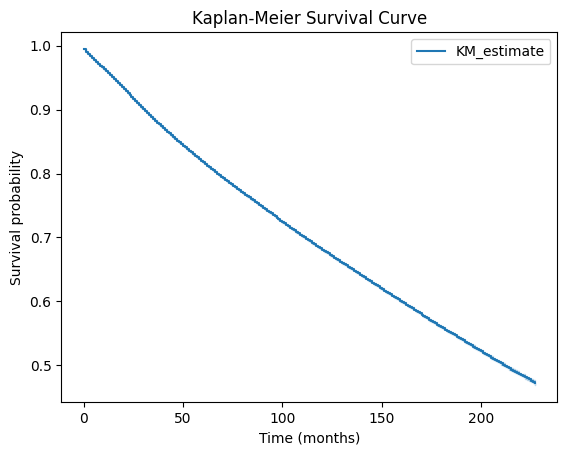

In [13]:
kmf.plot()

plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")
plt.show()

In [14]:
df = pd.read_csv(
    r"D:\Sushant\Documents\oncology_survival_project\data\seer\seer_analysis_dataset.csv"
)

print("Shape:", df.shape)

Shape: (1132076, 8)


In [15]:
df = df.copy()

# Rename
df = df.rename(columns={'time': 'survival_months'})

# Drop minimal required NA
df = df.dropna(subset=['survival_months', 'event', 'stage_clean'])

# Handle grade
df['grade_clean'] = df['grade_clean'].fillna(-1)

# Encode categorical
df = pd.get_dummies(df, columns=['stage_clean'], drop_first=True)

print(df.shape)

(1132076, 9)


In [16]:
from lifelines import CoxPHFitter

features = [col for col in df.columns if col not in ['survival_months', 'event']]

df_cox = df[features + ['survival_months', 'event']].copy()

cph = CoxPHFitter()
cph.fit(df_cox, duration_col='survival_months', event_col='event')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1.13208e+06 total observations, 825889 right-censored observations>
             duration col = 'survival_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1.13208e+06
number of events observed = 306187
   partial log-likelihood = -3902016.65
         time fit was run = 2026-04-06 03:45:20 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
age                    0.05      1.05      0.00            0.05            0.05                1.05                1.05
grade_clean           -0.05      0.95      0.00           -0.05           -0.04                0.95                0.96
chemo                 -0.02      0.98      0.00           -0.02           -0.01                0.98                0.99
radiation             -0.34      0.71      0.00           -0.35           -0.33                0.71                0.72
surgery               -0.95      0.39      0.01           -0.96           -0.94                0.38                0.39
stage_clean_Localized -1.72      0.18      0.01           -1.74           -1.71                0.18                0.18
stage_clean_Regional  -1.07      0.34      0.01           -1.09           -1.06                0.34                0.35

                       cmp to       z      p  -log2(p)
covariate                                             
age                      0.00  330.24 <0.005       inf
grade_clean              0.00  -21.35 <0.005    333.68
chemo                    0.00   -3.47 <0.005     10.91
radiation                0.00  -87.27 <0.005       inf
surgery                  0.00 -158.83 <0.005       inf
stage_clean_Localized    0.00 -249.68 <0.005       inf
stage_clean_Regional     0.00 -158.61 <0.005       inf
---
Concordance = 0.78
Partial AIC = 7804047.30
log-likelihood ratio test = 315655.33 on 7 df
-log2(p) of ll-ratio test = inf

In [17]:
surv_fn = cph.predict_survival_function(df_cox, times=[36])
df['cox_prob'] = 1 - surv_fn.T.squeeze().values

df['cox_prob'].describe()

count    1.132076e+06
mean     1.173025e-01
std      1.499458e-01
min      3.082145e-03
25%      3.945851e-02
50%      6.773066e-02
75%      1.265113e-01
max      9.912941e-01
Name: cox_prob, dtype: float64

In [18]:
(df['survival_months'] <= 36).mean(), df['event'].mean()

(np.float64(0.2930916298905727), np.float64(0.2704650571163067))

In [19]:
observed_36m = ((df['survival_months'] <= 36) & (df['event'] == 1)).mean()
observed_36m

np.float64(0.10568371734759857)

In [20]:
features = [col for col in df.columns if col not in ['survival_months','event']]

In [21]:
from sksurv.util import Surv

y_struct = Surv.from_dataframe('event', 'survival_months', df)
X = df[features]

In [22]:
from sksurv.ensemble import RandomSurvivalForest

rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=20,
    min_samples_leaf=10,
    max_depth=10,
    n_jobs=1, # 🔥 critical fix
    random_state=42
)

rsf.fit(X, y_struct)

,n_estimators,100
,max_depth,10
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,1
,random_state,42


In [23]:
surv_probs = rsf.predict_survival_function(X, return_array=True)
df['rsf_prob'] = 1 - surv_probs[:, -1]

In [24]:
df[['cox_prob','rsf_prob']].describe()

,cox_prob,rsf_prob
count,1.132076e+06,1.132076e+06
mean,1.173025e-01,4.491657e-01
std,1.499458e-01,2.981810e-01
min,3.082145e-03,5.343330e-02
25%,3.945851e-02,1.854965e-01
50%,6.773066e-02,3.543381e-01
75%,1.265113e-01,6.788312e-01
max,9.912941e-01,1.000000e+00


In [25]:
time_grid = rsf.predict_survival_function(X.iloc[:1])[0].x

In [26]:
import numpy as np

t_idx = np.argmin(np.abs(time_grid - 36))

In [27]:
batch_size = 100000
rsf_probs = []

for i in range(0, len(X), batch_size):
    X_batch = X.iloc[i:i+batch_size]
    surv_batch = rsf.predict_survival_function(X_batch, return_array=True)
    rsf_probs.append(1 - surv_batch[:, t_idx])

df['rsf_prob'] = np.concatenate(rsf_probs)

In [28]:
df[['cox_prob','rsf_prob']].describe()

,cox_prob,rsf_prob
count,1.132076e+06,1.132076e+06
mean,1.173025e-01,1.172175e-01
std,1.499458e-01,1.626137e-01
min,3.082145e-03,8.231781e-03
25%,3.945851e-02,2.618750e-02
50%,6.773066e-02,5.527439e-02
75%,1.265113e-01,1.156633e-01
max,9.912941e-01,9.426217e-01


In [29]:
df['event_36m'] = ((df['survival_months'] <= 36) & (df['event'] == 1)).astype(int)

In [30]:
from sklearn.calibration import calibration_curve

prob_true_cox, prob_pred_cox = calibration_curve(
    df['event_36m'],
    df['cox_prob'],
    n_bins=10
)

In [31]:
prob_true_rsf, prob_pred_rsf = calibration_curve(
    df['event_36m'],
    df['rsf_prob'],
    n_bins=10
)

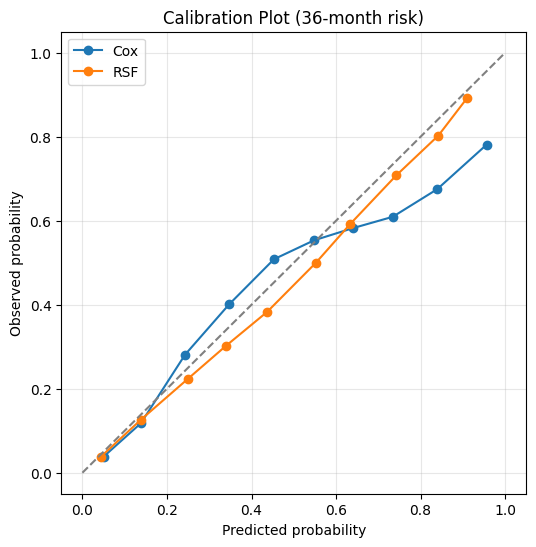

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.plot(prob_pred_cox, prob_true_cox, marker='o', label='Cox')
plt.plot(prob_pred_rsf, prob_true_rsf, marker='o', label='RSF')

# perfect calibration line
plt.plot([0,1], [0,1], '--', color='gray')

plt.xlabel('Predicted probability')
plt.ylabel('Observed probability')
plt.title('Calibration Plot (36-month risk)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [33]:
y_true = df['event_36m']

In [34]:
df['cox_prob']
df['rsf_prob']

0          0.036372
1          0.053648
2          0.124072
3          0.183767
4          0.071256
             ...   
1132071    0.104581
1132072    0.008380
1132073    0.008380
1132074    0.011891
1132075    0.104581
Name: rsf_prob, Length: 1132076, dtype: float64

In [35]:
import numpy as np

def net_benefit(y_true, y_prob, thresholds):
    n = len(y_true)
    nb = []

    for t in thresholds:
        preds = (y_prob >= t).astype(int)

        TP = ((preds == 1) & (y_true == 1)).sum()
        FP = ((preds == 1) & (y_true == 0)).sum()

        nb_t = (TP / n) - (FP / n) * (t / (1 - t))
        nb.append(nb_t)

    return np.array(nb)

In [36]:
thresholds = np.linspace(0.01, 0.5, 50)

In [37]:
nb_cox = net_benefit(y_true, df['cox_prob'], thresholds)
nb_rsf = net_benefit(y_true, df['rsf_prob'], thresholds)

# treat-all strategy
prevalence = y_true.mean()
nb_all = prevalence - (1 - prevalence) * (thresholds / (1 - thresholds))

# treat-none = 0
nb_none = np.zeros_like(thresholds)

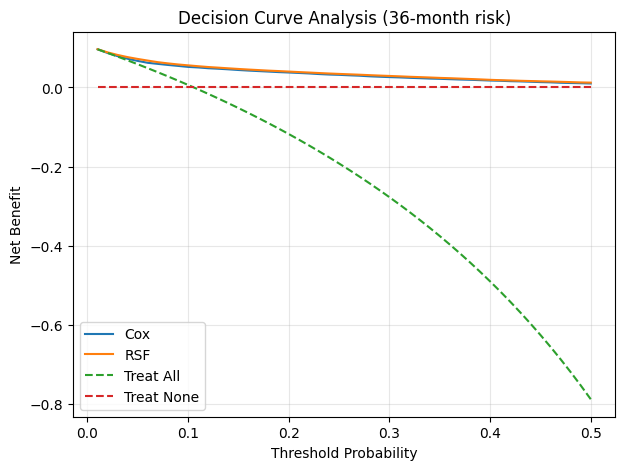

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(thresholds, nb_cox, label='Cox')
plt.plot(thresholds, nb_rsf, label='RSF')

plt.plot(thresholds, nb_all, '--', label='Treat All')
plt.plot(thresholds, nb_none, '--', label='Treat None')

plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')
plt.title('Decision Curve Analysis (36-month risk)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
kmf = KaplanMeierFitter()

for group in df["her2_status"].unique():
    
    mask = df["her2_status"] == group
    
    kmf.fit(T[mask], E[mask], label=group)
    
    kmf.plot()

In [ ]:
plt.title("Survival by HER2 Status")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")
plt.show()

In [ ]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for group in df["her2_status"].unique():
    
    mask = df["her2_status"] == group
    
    kmf.fit(df.loc[mask,"survival_months"],
            df.loc[mask,"event"],
            label=group)
    
    kmf.plot()

plt.title("Survival by HER2 Status")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")

plt.show()

In [ ]:
df["her2_status"].value_counts()

In [ ]:
from lifelines import CoxPHFitter

In [ ]:
df_model = df.copy()

df_model["her2_status"] = df_model["her2_status"].map({"negative":0,"positive":1})
df_model["er_status"] = df_model["er_status"].map({"negative":0,"positive":1})

df_model.head()

In [ ]:
cph = CoxPHFitter()

cph.fit(df_model,
        duration_col="survival_months",
        event_col="event")

cph.print_summary()

In [ ]:
print(df_model.shape)
print(df_model.columns.tolist())
df_model[['survival_months','event']].head()

In [ ]:
cox_risk = cph.predict_partial_hazard(df_model)

In [ ]:
df_model['cox_risk_score'] = cox_risk

In [ ]:
df_model[['cox_risk_score']].head()

In [ ]:
print(len(df_model), len(cox_risk))

In [ ]:
pip install scikit-survival

In [ ]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv

In [ ]:
X = df_model.drop(columns=['survival_months','event'])

y = Surv.from_dataframe(
    event='event',
    time='survival_months',
    data=df_model
)

In [ ]:
rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rsf.fit(X, y)

In [ ]:
rsf_risk = rsf.predict(X)

In [ ]:
df_model['rsf_risk_score'] = rsf_risk

In [ ]:
df_model[['cox_risk_score','rsf_risk_score']].head()

In [ ]:
print(len(df_model), len(rsf_risk))

In [ ]:
import xgboost as xgb

In [ ]:
X = df_model.drop(columns=['survival_months','event'])

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
y_time = df_model['survival_months'].values
y_event = df_model['event'].values

In [ ]:
dtrain = xgb.DMatrix(X, label=y_time)

In [ ]:
dtrain.set_float_info('label_lower_bound', y_time)
dtrain.set_float_info('label_upper_bound', y_time)

# censoring
dtrain.set_float_info('weight', y_event)

In [ ]:
params = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'seed': 42
}

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=100
)

In [ ]:
xgb_risk = xgb_model.predict(dtrain)

In [ ]:
df_model['xgb_risk_score'] = xgb_risk

In [ ]:
df_model[['cox_risk_score','rsf_risk_score','xgb_risk_score']].head()

In [ ]:
HORIZON = 36

df_model['event_36m'] = (
    (df_model['survival_months'] <= HORIZON) & (df_model['event'] == 1)
).astype(int)

In [ ]:
surv_fn_cox = cph.predict_survival_function(df_model, times=[36])

df_model['cox_prob'] = 1 - surv_fn_cox.T.squeeze().values

In [ ]:
X_rsf = df_model.drop(columns=['survival_months','event','event_36m'])

X_rsf = pd.get_dummies(X_rsf, drop_first=True)

In [ ]:
X_rsf = X_rsf.reindex(columns=rsf.feature_names_in_, fill_value=0)

In [ ]:
surv_fn_rsf = rsf.predict_survival_function(X_rsf)

In [ ]:
df_model['rsf_prob'] = np.array([
    1 - fn(36) for fn in surv_fn_rsf
])

In [ ]:
df_model[['cox_prob','rsf_prob']].describe()

In [ ]:
X = df_model.drop(columns=['survival_months','event','event_36m'])

surv_fn_rsf = rsf.predict_survival_function(X)

df_model['rsf_prob'] = np.array([
    1 - fn(36) for fn in surv_fn_rsf
])

In [ ]:
df_model[['cox_prob','rsf_prob','xgb_prob']].describe()

In [ ]:
import numpy as np

def net_benefit(y_true, y_prob, thresholds):
    N = len(y_true)
    nb = []

    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)

        TP = ((pred == 1) & (y_true == 1)).sum()
        FP = ((pred == 1) & (y_true == 0)).sum()

        val = (TP/N) - (FP/N)*(pt/(1-pt))
        nb.append(val)

    return np.array(nb)

In [ ]:
thresholds = np.linspace(0.01, 0.9, 50)

y = df_model['event_36m'].values

nb_cox = net_benefit(y, df_model['cox_prob'], thresholds)
nb_rsf = net_benefit(y, df_model['rsf_prob'], thresholds)
nb_xgb = net_benefit(y, df_model['xgb_prob'], thresholds)

In [ ]:
event_rate = y.mean()

nb_all = event_rate - (1 - event_rate)*(thresholds/(1-thresholds))
nb_none = np.zeros_like(thresholds)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(thresholds, nb_cox, label='Cox')
plt.plot(thresholds, nb_rsf, label='RSF')
plt.plot(thresholds, nb_xgb, label='XGBoost')

plt.plot(thresholds, nb_all, '--', label='Treat All')
plt.plot(thresholds, nb_none, '--', label='Treat None')

plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')
plt.title('Decision Curve Analysis (36-month Survival)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print(len(df_model))
print(df_model['event_36m'].mean())

In [ ]:
rsf

In [ ]:
cph.plot()
plt.title("Cox Model Hazard Ratios")
plt.show()

In [ ]:
plt.figure(figsize=(8,6))

for group in df["her2_status"].unique():
    
    mask = df["her2_status"] == group
    
    kmf.fit(df.loc[mask,"survival_months"],
            df.loc[mask,"event"],
            label=group)
    
    kmf.plot()

plt.title("Survival by HER2 Status")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")

plt.savefig("../figures/km_her2_survival.png", dpi=300)

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

cph.plot()

plt.title("Hazard Ratios from Cox Model")

plt.savefig("../figures/cox_hazard_ratios.png", dpi=300)

plt.show()

In [ ]:
cph.summary

In [ ]:
df.shape

In [ ]:
df.head()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter

print("SEER survival analysis environment ready")

In [ ]:
# Placeholder dataframe for SEER data
df = pd.DataFrame()

print("Dataframe initialized")

Primary endpoint: Overall Survival

time variable:
survival_months

event variable:
event
1 = death
0 = censored

In [ ]:
import pandas as pd

df = pd.read_csv(r"D:\Sushant\Documents\oncology_survival_project\data_raw\seer_breast_cancer_2000_2022.csv")

df.head()

In [ ]:
df.shape


In [ ]:
df.columns

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.isna().sum()

In [ ]:
df['Survival months'].describe()
df['Vital status recode (study cutoff used)'].value_counts()

In [ ]:
df['event'] = df['Vital status recode (study cutoff used)'].map({
    'Alive':0,
    'Dead':1
})

In [ ]:
df['Sex'].value_counts()
df['Race recode (W, B, AI, API)'].value_counts()
df['Combined Summary Stage with Expanded Regional Codes (2004+)'].value_counts()

In [ ]:
df['Tumor Size Summary (2016+)'].describe()

In [ ]:
# convert survival months to numeric
df['Survival months'] = pd.to_numeric(df['Survival months'], errors='coerce')

# convert tumor size to numeric
df['Tumor Size Summary (2016+)'] = pd.to_numeric(
    df['Tumor Size Summary (2016+)'], errors='coerce'
)

# check conversion
df[['Survival months','Tumor Size Summary (2016+)']].info()

In [ ]:
df['event'] = df['Vital status recode (study cutoff used)'].map({
    'Alive':0,
    'Dead':1
})

In [ ]:
df['event'].value_counts()

In [ ]:
df['Survival months'].describe()

In [ ]:

df['Combined Summary Stage with Expanded Regional Codes (2004+)'].value_counts()

In [ ]:
stage_map = {
    'Localized only':'Localized',
    'Regional lymph nodes involved only':'Regional',
    'Regional by both direct extension and lymph node involvement':'Regional',
    'Regional by direct extension only':'Regional',
    'Distant site(s)/node(s) involved':'Distant'
}

df['stage_clean'] = df['Combined Summary Stage with Expanded Regional Codes (2004+)'].map(stage_map)

df['stage_clean'].value_counts(dropna=False)

In [ ]:
df = df.dropna(subset=['stage_clean'])

In [ ]:
df.shape


In [ ]:
df['Derived Summary Grade 2018 (2018+)'].value_counts()

In [ ]:
df['grade_clean'] = pd.to_numeric(
    df['Derived Summary Grade 2018 (2018+)'],
    errors='coerce'
)

df['grade_clean'].value_counts(dropna=False)

In [ ]:
df.loc[df['grade_clean'] == 9, 'grade_clean'] = None

In [ ]:
df['grade_clean'].value_counts(dropna=False)

In [ ]:
df['Radiation recode'].value_counts()

df['Chemotherapy recode (yes, no/unk)'].value_counts()

In [ ]:
df['Radiation recode'].value_counts()

In [ ]:
radiation_yes = [
    'Beam radiation',
    'Radioactive implants (includes brachytherapy) (1988+)',
    'Combination of beam with implants or isotopes',
    'Radioisotopes (1988+)',
    'Radiation, NOS  method or source not specified'
]

df['radiation'] = df['Radiation recode'].apply(
    lambda x: 1 if x in radiation_yes else 0
)

df['radiation'].value_counts()

In [ ]:
df['RX Summ--Surg Prim Site (1998+)'].describe()

In [ ]:
df['surgery'] = df['RX Summ--Surg Prim Site (1998+)'].apply(
    lambda x: 1 if x > 0 else 0
)

df['surgery'].value_counts()

In [ ]:
df['age'] = df['Age recode with <1 year olds and 90+'].str.extract('(\d+)').astype(int)

df['age'].describe()

In [ ]:
df['chemo'] = df['Chemotherapy recode (yes, no/unk)'].map({
    'Yes': 1,
    'No/Unknown': 0
})

df['chemo'].value_counts()

In [ ]:
df[['age','stage_clean','grade_clean','chemo','radiation','surgery','Survival months','event']].head()

In [ ]:
analysis_df = df[[
    'age',
    'stage_clean',
    'grade_clean',
    'chemo',
    'radiation',
    'surgery',
    'Survival months',
    'event'
]].copy()

analysis_df.head()

In [ ]:
analysis_df = analysis_df.rename(columns={
    'Survival months': 'time',
})

analysis_df.head()

In [ ]:
analysis_df.isna().sum()

In [ ]:
analysis_df = analysis_df.dropna(subset=['time'])

analysis_df.shape

In [ ]:
analysis_df.isna().sum()

In [ ]:
analysis_df['stage_clean'].value_counts(normalize=True)

In [ ]:
analysis_df['event'].value_counts()


In [ ]:
analysis_df['time'].describe()

In [ ]:
analysis_df[['chemo','radiation','surgery']].sum()

In [ ]:
analysis_df['age'].describe()

In [ ]:
analysis_df.to_csv(
    "../data/seer/seer_analysis_dataset.csv",
    index=False
)


In [ ]:
!pip install lifelines

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

In [ ]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=analysis_df['time'],
    event_observed=analysis_df['event']
)

plt.figure(figsize=(8,6))
kmf.plot_survival_function()

plt.title("Overall Survival - SEER Breast Cancer Cohort")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

for stage in analysis_df['stage_clean'].unique():
    
    stage_data = analysis_df[analysis_df['stage_clean'] == stage]
    
    kmf.fit(
        stage_data['time'],
        event_observed=stage_data['event'],
        label=stage
    )
    
    kmf.plot_survival_function()

plt.title("Survival by Cancer Stage")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

for s in analysis_df['surgery'].unique():
    
    subset = analysis_df[analysis_df['surgery'] == s]
    
    label = "Surgery" if s == 1 else "No Surgery"
    
    kmf.fit(
        subset['time'],
        event_observed=subset['event'],
        label=label
    )
    
    kmf.plot_survival_function()

plt.title("Survival by Surgery")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

for c in analysis_df['chemo'].unique():
    
    subset = analysis_df[analysis_df['chemo'] == c]
    
    label = "Chemotherapy" if c == 1 else "No Chemotherapy"
    
    kmf.fit(
        subset['time'],
        event_observed=subset['event'],
        label=label
    )
    
    kmf.plot_survival_function()

plt.title("Survival by Chemotherapy")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

for r in analysis_df['radiation'].unique():
    
    subset = analysis_df[analysis_df['radiation'] == r]
    
    label = "Radiation" if r == 1 else "No Radiation"
    
    kmf.fit(
        subset['time'],
        event_observed=subset['event'],
        label=label
    )
    
    kmf.plot_survival_function()

plt.title("Survival by Radiation")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

In [ ]:
analysis_df.groupby('stage_clean')['chemo'].mean()

In [ ]:
cox_df = analysis_df.dropna(subset=['grade_clean']).copy()

cox_df = pd.get_dummies(
    cox_df,
    columns=['stage_clean'],
    drop_first=True
)

In [ ]:
cox_df.columns

In [ ]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()

cph.fit(
    cox_df[['time','event','age','grade_clean','chemo','radiation','surgery',
            'stage_clean_Localized','stage_clean_Regional']],
    duration_col='time',
    event_col='event'
)

cph.print_summary()

In [ ]:
cph.plot()
plt.title("Hazard Ratios from Cox Model")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

cph.plot()

plt.title("Adjusted Hazard Ratios – SEER Breast Cancer Survival Model")
plt.xlabel("Hazard Ratio (log scale)")
plt.show()

In [ ]:
# cph.check_assumptions(cox_df, p_value_threshold=0.05)

In [ ]:
# cph.check_assumptions(cox_df, show_plots=True)

In [ ]:
# cph.check_assumptions(cox_df, show_plots=False)

In [ ]:
cox_df.dtypes

In [ ]:
print(cox_df.shape)

In [ ]:
cox_df.head()

In [ ]:
# 🔹 FINAL FEATURE MATRIX (single source of truth)

X = cox_df.drop(columns=["time", "event"], errors="ignore")

X = X.astype(float)

from sksurv.util import Surv
y = Surv.from_dataframe("event", "time", cox_df)

In [ ]:
X.dtypes

In [ ]:
X = cox_df.drop(columns=[
    "time",
    "event",
    "risk_score",
    "risk_group",
    "xgb_risk_score",
    "xgb_risk_group",
    "cox_risk_score",
    "cox_risk_group"
], errors="ignore")

In [ ]:
X = X.astype(float)

In [ ]:
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest

from sksurv.util import Surv

y = Surv.from_dataframe("event", "time", cox_df)

X = cox_df.drop(columns=[
    "time",
    "event",
    "risk_score",
    "risk_group",
    "xgb_risk_score",
    "xgb_risk_group",
    "cox_risk_score",
    "cox_risk_group"
], errors="ignore")

X = X.astype(float)

rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X, y)

In [ ]:
# ✅ FIX: Align indices properly (for structured survival y)

X = X.reset_index(drop=True)

y = pd.DataFrame({
    "event": y["event"],
    "time": y["time"]
}).reset_index(drop=True)

In [ ]:
from sklearn.inspection import permutation_importance

# controlled subsampling (retain distribution)
# Subsample
X_sample = X.sample(n=50000, random_state=42)
y_sample = y.loc[X_sample.index]

# Convert back to structured format
from sksurv.util import Surv
y_sample_struct = Surv.from_dataframe("event", "time", y_sample)

# Permutation importance
result = permutation_importance(
    rsf,
    X_sample,
    y_sample_struct,
    n_repeats=3,
    random_state=42,
    n_jobs=1
)

importance = pd.Series(
    result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

importance

In [ ]:
# 🔹 REBUILD CLEAN PIPELINE (authoritative block)

from sksurv.util import Surv

# fresh X
X = cox_df.drop(columns=["time", "event"], errors="ignore").copy()
X = X.astype(float)

# fresh y (DO NOT reuse old y)
y = Surv.from_dataframe("event", "time", cox_df)

In [ ]:
from sksurv.ensemble import RandomSurvivalForest

rsf = RandomSurvivalForest(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X, y)

In [ ]:
from sksurv.ensemble import RandomSurvivalForest

rsf = RandomSurvivalForest(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X, y)

In [ ]:
import numpy as np
from sklearn.inspection import permutation_importance

sample_idx = np.random.choice(len(X), size=50000, replace=False)

X_sample = X.iloc[sample_idx]
y_sample = y[sample_idx]

result = permutation_importance(
    rsf,
    X_sample,
    y_sample,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

importance

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
importance.plot.bar()

plt.title("Random Survival Forest Feature Importance")
plt.ylabel("Permutation Importance")

plt.savefig(f"{FIG_PATH}/rsf_feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
risk_scores = rsf.predict(X)

cox_df["risk_score"] = risk_scores

In [ ]:
cox_df["risk_group"] = pd.qcut(
    cox_df["risk_score"],
    q=3,
    labels=["Low Risk","Medium Risk","High Risk"]
)

In [ ]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for group in cox_df["risk_group"].unique():

    mask = cox_df["risk_group"] == group

    kmf.fit(
        durations=cox_df.loc[mask,"time"],
        event_observed=cox_df.loc[mask,"event"],
        label=group
    )

    kmf.plot_survival_function()

plt.title("Survival by RSF Predicted Risk Groups")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

In [ ]:
import xgboost as xgb
xgb.__version__

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
print(xgb.__version__)

In [ ]:
import numpy as np
import xgboost as xgb

X_xgb = X.copy()

y_time = cox_df["time"].values
y_event = cox_df["event"].values

# XGBoost Cox expects negative time for censored observations
y_xgb = np.where(y_event == 1, y_time, -y_time)

dtrain = xgb.DMatrix(X_xgb, label=y_xgb)

In [ ]:
params = {
    "objective": "survival:cox",
    "eval_metric": "cox-nloglik",
    "tree_method": "hist",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}

In [ ]:
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=300
)

In [ ]:
params = {
    "objective": "survival:cox",
    "eval_metric": "cox-nloglik",
    "tree_method": "hist",   # CPU optimized
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}

In [ ]:
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=300
)

In [ ]:
xgb_risk = xgb_model.predict(dtrain)

cox_df["xgb_risk_score"] = xgb_risk

In [ ]:
cox_df["xgb_risk_group"] = pd.qcut(
    cox_df["xgb_risk_score"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for group in cox_df["xgb_risk_group"].unique():

    mask = cox_df["xgb_risk_group"] == group

    kmf.fit(
        durations=cox_df.loc[mask, "time"],
        event_observed=cox_df.loc[mask, "event"],
        label=group
    )

    kmf.plot_survival_function()

plt.title("Survival by XGBoost Predicted Risk Groups")
plt.xlabel("Months")
plt.ylabel("Survival Probability")

plt.show()

In [ ]:
cox_df["cox_risk_score"] = cph.predict_partial_hazard(cox_df)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

risk_compare = cox_df[
    ["cox_risk_score", "risk_score", "xgb_risk_score"]
]

plt.figure(figsize=(6,5))

sns.heatmap(
    risk_compare.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Survival Risk Predictions")

plt.savefig(f"{FIG_PATH}/risk_score_correlation.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(cox_df["cox_risk_score"], label="Cox")
sns.kdeplot(cox_df["risk_score"], label="RSF")
sns.kdeplot(cox_df["xgb_risk_score"], label="XGBoost")

plt.title("Distribution of Predicted Survival Risk")
plt.xlabel("Risk Score")
plt.legend()

plt.show()

In [ ]:
cox_df["cox_risk_group"] = pd.qcut(
    cox_df["cox_risk_score"],
    q=3,
    labels=["Low Risk","Medium Risk","High Risk"]
)

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

fig, axes = plt.subplots(1,3, figsize=(18,5))

models = {
    "Cox Model": "cox_risk_group",
    "Random Survival Forest": "risk_group",
    "XGBoost Survival": "xgb_risk_group"
}

for ax,(title,group_col) in zip(axes,models.items()):

    for group in cox_df[group_col].unique():

        mask = cox_df[group_col] == group

        kmf.fit(
            durations=cox_df.loc[mask,"time"],
            event_observed=cox_df.loc[mask,"event"],
            label=group
        )

        kmf.plot_survival_function(ax=ax)

    ax.set_title(title)
    ax.set_xlabel("Months")
    ax.set_ylabel("Survival Probability")

plt.tight_layout()

plt.savefig(f"{FIG_PATH}/model_risk_stratification.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
plt.savefig("figure_name.png", dpi=300, bbox_inches="tight")

In [ ]:
!pip install lifelines

In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
import matplotlib.pyplot as plt

In [ ]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

ax = plt.subplot(111)

models = ["Low Risk","Medium Risk","High Risk"]

for group in models:

    mask = cox_df["risk_group"] == group

    kmf.fit(
        durations=cox_df.loc[mask,"time"],
        event_observed=cox_df.loc[mask,"event"],
        label=group
    )

    kmf.plot_survival_function(
        ax=ax,
        ci_show=True,
        linewidth=2
    )

add_at_risk_counts(
    *[kmf.fit(
        cox_df.loc[cox_df["risk_group"] == g,"time"],
        cox_df.loc[cox_df["risk_group"] == g,"event"]
      ) for g in models],
    ax=ax
)

plt.title("Survival Stratification by Random Survival Forest Risk Groups")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")

plt.tight_layout()

plt.savefig(f"{FIG_PATH}/rsf_survival_stratification.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
import matplotlib.pyplot as plt

km_low = KaplanMeierFitter()
km_med = KaplanMeierFitter()
km_high = KaplanMeierFitter()

mask_low = cox_df["risk_group"] == "Low Risk"
mask_med = cox_df["risk_group"] == "Medium Risk"
mask_high = cox_df["risk_group"] == "High Risk"

km_low.fit(
    cox_df.loc[mask_low, "time"],
    cox_df.loc[mask_low, "event"],
    label="Low Risk"
)

km_med.fit(
    cox_df.loc[mask_med, "time"],
    cox_df.loc[mask_med, "event"],
    label="Medium Risk"
)

km_high.fit(
    cox_df.loc[mask_high, "time"],
    cox_df.loc[mask_high, "event"],
    label="High Risk"
)

plt.figure(figsize=(8,6))
ax = plt.subplot(111)

km_low.plot_survival_function(ax=ax, ci_show=True, linewidth=2)
km_med.plot_survival_function(ax=ax, ci_show=True, linewidth=2)
km_high.plot_survival_function(ax=ax, ci_show=True, linewidth=2)

add_at_risk_counts(km_low, km_med, km_high, ax=ax)

plt.title("Survival Stratification by Random Survival Forest Risk Groups")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")

plt.tight_layout()
plt.show()

In [ ]:
from lifelines.utils import concordance_index

In [ ]:
cox_cindex = concordance_index(
    cox_df["time"],
    -cox_df["cox_risk_score"],
    cox_df["event"]
)

cox_cindex

In [ ]:
cox_cindex = concordance_index(
    cox_df["time"],
    -cox_df["cox_risk_score"],
    cox_df["event"]
)

cox_cindex

In [ ]:
rsf_cindex = concordance_index(
    cox_df["time"],
    -cox_df["risk_score"],
    cox_df["event"]
)

rsf_cindex

In [ ]:
from lifelines.utils import concordance_index

cox_cindex = concordance_index(
    cox_df["time"],
    -cox_df["cox_risk_score"],
    cox_df["event"]
)

print("Cox C-index:", cox_cindex)

In [ ]:
from lifelines.utils import concordance_index

cox_cindex = concordance_index(
    cox_df["time"],
    -cox_df["cox_risk_score"],
    cox_df["event"]
)

print("Cox C-index:", cox_cindex)

In [ ]:
xgb_cindex = concordance_index(
    cox_df["time"],
    -cox_df["xgb_risk_score"],
    cox_df["event"]
)

print("XGBoost C-index:", xgb_cindex)

In [ ]:
xgb_cindex = concordance_index(
    cox_df["time"],
    -cox_df["xgb_risk_score"],
    cox_df["event"]
)

print("XGBoost C-index:", xgb_cindex)

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Cox PH", "Random Survival Forest", "XGBoost Survival"],
    "C-index": [cox_cindex, rsf_cindex, xgb_cindex]
})

results

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["C-index"])

plt.ylabel("Concordance Index")
plt.title("Survival Model Performance Comparison")

plt.ylim(0.5,1)

plt.savefig(f"{FIG_PATH}/model_performance_cindex.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
# ================================
# WEEK 4: Kaplan–Meier (Stage-based)
# ================================

import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

# --- Safety check ---
required_cols = ["time", "event"]
for col in required_cols:
    if col not in cox_df.columns:
        raise ValueError(f"Missing required column: {col}")

# --- Stage handling (robust) ---
if "stage_clean_Localized" in cox_df.columns:
    cox_df["stage_group"] = np.where(
        cox_df["stage_clean_Localized"] == 1,
        "Localized",
        "Regional"
    )
else:
    raise ValueError("stage_clean_Localized column not found in cox_df")

# --- Plot ---
plt.figure(figsize=(8,6))

for group in cox_df["stage_group"].unique():
    mask = cox_df["stage_group"] == group

    kmf.fit(
        durations=cox_df.loc[mask, "time"],
        event_observed=cox_df.loc[mask, "event"],
        label=group
    )

    kmf.plot()

# --- Labels ---
plt.title("Survival by Stage (Localized vs Regional)")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")

# --- Export ---
plt.savefig("km_stage_survival.png", dpi=300, bbox_inches="tight")

plt.show()

print("✅ KM plot generated and saved as: km_stage_survival.png")

In [ ]:
# ================================
# WEEK 4: KM by Model Risk Groups
# ================================

import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

# --- Safety check ---
required_cols = ["time", "event", "risk_group"]
for col in required_cols:
    if col not in cox_df.columns:
        raise ValueError(f"Missing required column: {col}")

plt.figure(figsize=(8,6))

# --- Loop through model risk groups ---
for group in sorted(cox_df["risk_group"].dropna().unique()):
    mask = cox_df["risk_group"] == group

    kmf.fit(
        durations=cox_df.loc[mask, "time"],
        event_observed=cox_df.loc[mask, "event"],
        label=str(group)
    )

    kmf.plot()

# --- Labels ---
plt.title("Survival by Model-Predicted Risk Groups")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")

# --- Export ---
plt.savefig("km_risk_group_survival.png", dpi=300, bbox_inches="tight")

plt.show()

print("✅ KM risk-group plot saved as: km_risk_group_survival.png")

In [ ]:
import numpy as np
import pandas as pd

# Define time horizon (months)
HORIZON = 36

# Binary outcome: event within 36 months
df['event_36m'] = np.where((df['time'] <= HORIZON) & (df['event'] == 1), 1, 0)

In [ ]:
print(df.columns.tolist())

In [ ]:
df.head()

In [ ]:
df = df.rename(columns={
    'Survival months': 'time'
})

In [ ]:
print(df[['time','event']].head())
print(df['event'].value_counts())

In [ ]:
import numpy as np
import pandas as pd

# Define time horizon (months)
HORIZON = 36

# Binary outcome: event within 36 months
df['event_36m'] = np.where((df['time'] <= HORIZON) & (df['event'] == 1), 1, 0)

In [ ]:
from scipy.special import expit  # sigmoid

# Scale each model independently (robust normalization)
def scale_to_prob(x):
    x = (x - np.mean(x)) / (np.std(x) + 1e-8)
    return expit(x)

df['cox_prob'] = scale_to_prob(df['cox_risk_score'])
df['rsf_prob'] = scale_to_prob(df['rsf_risk_score'])
df['xgb_prob'] = scale_to_prob(df['xgb_risk_score'])

In [ ]:
print(df.columns.tolist())

In [ ]:
cox_
rsf_
xgb_
predict
predict_risk
predict_partial_hazard

In [ ]:
df['cox_risk_score'] = cox_risk
df['rsf_risk_score'] = rsf_risk
df['xgb_risk_score'] = xgb_risk